# Machine Learning in Finance: Final Project
### Alan Donnelly, Andrew McLaughlin, Chris Mulligan, Robert Asgeirsson

---

In [249]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

---

# Functions

### PART 1: DATA LOADING AND FEATURE ENGINEERING

In [ ]:
def load_and_prepare_data(filepath='Data/Betting Data/nba_2008-2025.csv'):
    """Load NBA data and create basic columns."""
    df = pd.read_csv(filepath)
    
    # Parse date
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    
    # Create target: actual total points
    df['actual_total'] = df['score_away'] + df['score_home']
    
    # Create outcome: did the over hit?
    df['over_hit'] = (df['actual_total'] > df['total']).astype(int)
    
    # Points scored/allowed by each team
    df['home_pts'] = df['score_home']
    df['away_pts'] = df['score_away']
    df['home_allowed'] = df['score_away']  # points home team allowed
    df['away_allowed'] = df['score_home']  # points away team allowed
    
    # Win indicator
    df['home_win'] = (df['score_home'] > df['score_away']).astype(int)
    
    print(f"Loaded {len(df):,} games from {df['date'].min().date()} to {df['date'].max().date()}")
    
    return df


def compute_rolling_stats(df, team_col, date_col='date', windows=[5, 10]):
    """
    Compute rolling statistics for each team.
    
    This creates features like:
    - Average points scored in last N games
    - Average points allowed in last N games
    - Win percentage in last N games
    """
    # Create a long-form dataset with one row per team per game
    home_games = df[['date', 'home', 'home_pts', 'home_allowed', 'home_win', 'actual_total']].copy()
    home_games.columns = ['date', 'team', 'pts_scored', 'pts_allowed', 'win', 'game_total']
    home_games['is_home'] = 1
    
    away_games = df[['date', 'away', 'away_pts', 'away_allowed', 'actual_total']].copy()
    away_games['win'] = 1 - df['home_win']  # away team wins when home team loses
    away_games.columns = ['date', 'team', 'pts_scored', 'pts_allowed', 'win', 'game_total']
    away_games['is_home'] = 0
    
    all_games = pd.concat([home_games, away_games]).sort_values('date')
    
    # Compute rolling stats for each team
    rolling_stats = {}
    
    for team in all_games['team'].unique():
        team_games = all_games[all_games['team'] == team].copy()
        team_games = team_games.sort_values('date')
        
        for w in windows:
            # Shift by 1 to avoid lookahead bias (use stats BEFORE this game)
            team_games[f'pts_scored_L{w}'] = team_games['pts_scored'].shift(1).rolling(w, min_periods=1).mean()
            team_games[f'pts_allowed_L{w}'] = team_games['pts_allowed'].shift(1).rolling(w, min_periods=1).mean()
            team_games[f'win_pct_L{w}'] = team_games['win'].shift(1).rolling(w, min_periods=1).mean()
            team_games[f'game_total_L{w}'] = team_games['game_total'].shift(1).rolling(w, min_periods=1).mean()
        
        rolling_stats[team] = team_games
    
    return pd.concat(rolling_stats.values())


def create_game_features(df):
    """
    Create feature matrix for each game.
    """
    print("Computing rolling statistics (this may take a minute)...")
    
    # Get rolling stats
    rolling = compute_rolling_stats(df, 'team', windows=[5, 10])
    
    # Prepare to merge back to original games
    features = df[['date', 'home', 'away', 'total', 'spread', 'actual_total', 'over_hit', 'season']].copy()
    
    # Get home team stats - ONLY ROLLING COLUMNS (must have '_L' in name)
    home_stats = rolling[rolling['is_home'] == 1].copy()
    home_cols = [c for c in home_stats.columns if '_L' in c]
    home_stats = home_stats[['date', 'team'] + home_cols]
    home_stats.columns = ['date', 'home'] + ['H_' + c for c in home_cols]
    features = features.merge(home_stats, on=['date', 'home'], how='left')
    
    # Get away team stats - ONLY ROLLING COLUMNS
    away_stats = rolling[rolling['is_home'] == 0].copy()
    away_cols = [c for c in away_stats.columns if '_L' in c]
    away_stats = away_stats[['date', 'team'] + away_cols]
    away_stats.columns = ['date', 'away'] + ['A_' + c for c in away_cols]
    features = features.merge(away_stats, on=['date', 'away'], how='left')
    
    # Add combined features
    for w in [5, 10]:
        features[f'combined_pts_L{w}'] = features[f'H_pts_scored_L{w}'] + features[f'A_pts_scored_L{w}']
        features[f'combined_allowed_L{w}'] = features[f'H_pts_allowed_L{w}'] + features[f'A_pts_allowed_L{w}']
        features[f'expected_total_L{w}'] = (
            features[f'H_pts_scored_L{w}'] + features[f'A_pts_scored_L{w}'] +
            features[f'H_pts_allowed_L{w}'] + features[f'A_pts_allowed_L{w}']
        ) / 2
    
    # Vegas line as feature
    features['vegas_total'] = features['total']
    features['vegas_spread'] = features['spread']
    
    # Drop rows with missing features and LOG how many
    n_before = len(features)
    features = features.dropna()
    n_after = len(features)
    n_dropped = n_before - n_after
    
    print(f"Created {n_after:,} games with features (dropped {n_dropped} rows with missing data)")
    
    return features


def get_feature_columns(df):
    """Return list of feature columns (X) - only rolling stats, not actual outcomes."""
    # Exclude all metadata AND actual game outcomes
    exclude = [
        'date', 'home', 'away', 'total', 'actual_total', 'over_hit', 'season', 'spread',
        # ALSO EXCLUDE THESE - they're actual outcomes, not features!
        'home_pts', 'away_pts', 'home_allowed', 'away_allowed', 'home_win',
        'score_home', 'score_away',  # just in case
        'regular', 'playoffs', 'whos_favored', 'moneyline_away', 'moneyline_home',
        'h2_spread', 'h2_total', 'id_spread', 'id_total',
        'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away',
        'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home'
    ]
    feature_cols = [c for c in df.columns if c not in exclude]
    return feature_cols

### PART 2: MODEL TRAINING AND EVALUATION

In [251]:
def train_test_split_by_season(df, test_seasons=[2023, 2024, 2025]):
    """Split data by season for proper out-of-sample testing."""
    train = df[~df['season'].isin(test_seasons)].copy()
    test = df[df['season'].isin(test_seasons)].copy()
    
    print(f"Train: {len(train):,} games (seasons {train['season'].min()}-{train['season'].max()})")
    print(f"Test:  {len(test):,} games (seasons {test['season'].min()}-{test['season'].max()})")
    
    return train, test


def evaluate_predictions(y_true, y_pred, vegas_line, method_name="Model", threshold=3, odds=-110):
    """
    Evaluate predictions for betting performance.
    
    Parameters:
    -----------
    y_true : array - actual total points
    y_pred : array - predicted total points
    vegas_line : array - Vegas over/under line
    method_name : str - name for results
    threshold : float - minimum disagreement with Vegas to bet (default 3 points)
    odds : int - betting odds (default -110, meaning bet 110 to win 100)
    
    Betting strategy: If prediction > vegas_line, bet OVER; else bet UNDER
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    vegas_line = np.array(vegas_line)
    
    # Prediction accuracy (RMSE)
    rmse = np.sqrt(np.mean((y_true - y_pred)**2))
    
    # Betting decisions
    bet_over = y_pred > vegas_line
    actual_over = y_true > vegas_line
    
    # Accuracy
    correct = bet_over == actual_over
    accuracy = np.mean(correct)
    
    # ROI calculation based on odds
    # For -110 odds: Win +1 unit, Lose -1.1 units
    # For -105 odds: Win +1 unit, Lose -1.05 units
    # General formula: lose_amount = abs(odds)/100 if odds < 0
    lose_amount = abs(odds) / 100
    wins = np.sum(correct)
    losses = np.sum(~correct)
    profit = wins * 1.0 - losses * lose_amount
    roi = profit / len(y_true) * 100  # as percentage per bet
    
    # Only bet when confident (|prediction - line| > threshold)
    confident_bets = np.abs(y_pred - vegas_line) > threshold
    if np.sum(confident_bets) > 0:
        confident_correct = correct[confident_bets]
        confident_accuracy = np.mean(confident_correct)
        confident_wins = np.sum(confident_correct)
        confident_losses = np.sum(~confident_correct)
        confident_profit = confident_wins * 1.0 - confident_losses * lose_amount
        confident_roi = confident_profit / np.sum(confident_bets) * 100
        n_confident = np.sum(confident_bets)
    else:
        confident_accuracy = 0
        confident_roi = 0
        n_confident = 0
    
    return {
        'method': method_name,
        'rmse': rmse,
        'accuracy': accuracy,
        'roi_all_bets': roi,
        'confident_accuracy': confident_accuracy,
        'confident_roi': confident_roi,
        'n_confident_bets': n_confident,
        'n_total_bets': len(y_true)
    }

def compute_vegas_baseline(y_true, vegas_line, odds=-110):
    """
    Compute the baseline performance of always betting with Vegas (the favorite side).
    
    In over/under markets, the "market baseline" is roughly 50% since lines are set 
    to balance action. This function computes actual over/under hit rates.
    """
    y_true = np.array(y_true)
    vegas_line = np.array(vegas_line)
    
    actual_over = y_true > vegas_line
    over_rate = np.mean(actual_over)
    under_rate = 1 - over_rate
    
    # The market baseline: if you always bet the more likely side
    # (This is still ~50% in efficient markets)
    baseline_accuracy = max(over_rate, under_rate)
    
    # ROI if always betting the majority side
    lose_amount = abs(odds) / 100
    if over_rate >= 0.5:
        wins = np.sum(actual_over)
        losses = np.sum(~actual_over)
    else:
        wins = np.sum(~actual_over)
        losses = np.sum(actual_over)
    
    profit = wins * 1.0 - losses * lose_amount
    roi = profit / len(y_true) * 100
    
    return {
        'over_rate': over_rate,
        'under_rate': under_rate,
        'baseline_accuracy': baseline_accuracy,
        'baseline_roi': roi,
        'n_games': len(y_true)
    }


def sweep_confidence_thresholds(y_true, y_pred, vegas_line, thresholds=[1, 2, 3, 4, 5, 6, 7], odds=-110):
    """
    Evaluate model performance across different confidence thresholds.
    
    This helps find the optimal threshold for selective betting.
    """
    results = []
    
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    vegas_line = np.array(vegas_line)
    
    lose_amount = abs(odds) / 100
    
    # Betting decisions
    bet_over = y_pred > vegas_line
    actual_over = y_true > vegas_line
    correct = bet_over == actual_over
    disagreement = np.abs(y_pred - vegas_line)
    
    for thresh in thresholds:
        confident_mask = disagreement > thresh
        n_bets = np.sum(confident_mask)
        
        if n_bets > 0:
            conf_correct = correct[confident_mask]
            accuracy = np.mean(conf_correct)
            wins = np.sum(conf_correct)
            losses = n_bets - wins
            profit = wins * 1.0 - losses * lose_amount
            roi = profit / n_bets * 100
        else:
            accuracy = 0
            roi = 0
        
        results.append({
            'threshold': thresh,
            'n_bets': n_bets,
            'accuracy': accuracy,
            'roi': roi,
            'profitable': roi > 0
        })
    
    return pd.DataFrame(results)


def bootstrap_roi_confidence_interval(y_true, y_pred, vegas_line, threshold=3, odds=-110, 
                                       n_bootstrap=1000, confidence=0.95):
    """
    Compute bootstrap confidence interval for ROI.
    
    This tells us if the ROI is statistically significant or just luck.
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    vegas_line = np.array(vegas_line)
    
    lose_amount = abs(odds) / 100
    
    # Get confident bets only
    bet_over = y_pred > vegas_line
    actual_over = y_true > vegas_line
    correct = bet_over == actual_over
    disagreement = np.abs(y_pred - vegas_line)
    confident_mask = disagreement > threshold
    
    if np.sum(confident_mask) < 10:
        return {'ci_lower': None, 'ci_upper': None, 'p_value': None, 'n_bets': np.sum(confident_mask)}
    
    # Get the confident bet outcomes (1 for win, -lose_amount for loss)
    outcomes = np.where(correct[confident_mask], 1.0, -lose_amount)
    n_bets = len(outcomes)
    
    # Bootstrap
    bootstrap_rois = []
    np.random.seed(42)
    for _ in range(n_bootstrap):
        sample = np.random.choice(outcomes, size=n_bets, replace=True)
        sample_roi = np.mean(sample) * 100  # as percentage
        bootstrap_rois.append(sample_roi)
    
    bootstrap_rois = np.array(bootstrap_rois)
    
    # Confidence interval
    alpha = 1 - confidence
    ci_lower = np.percentile(bootstrap_rois, alpha/2 * 100)
    ci_upper = np.percentile(bootstrap_rois, (1 - alpha/2) * 100)
    
    # P-value: proportion of bootstrap samples with ROI <= 0
    p_value = np.mean(bootstrap_rois <= 0)
    
    observed_roi = np.mean(outcomes) * 100
    
    return {
        'observed_roi': observed_roi,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': p_value,
        'n_bets': n_bets,
        'significant': p_value < 0.05
    }

def compute_market_baseline(y_true, vegas_line):
    """Compute a simple market baseline.

    - RMSE: treat `vegas_line` as a point prediction for total and compute RMSE.
    - Accuracy: proportion of games where actual > vegas_line.
    - ROI (naive market betting): choose the empirically better side (OVER if actual_over_rate>=0.5 else UNDER)
      and compute ROI for always betting that side at -110 odds. This is a conservative market baseline.
    """
    y_true = np.array(y_true)
    vegas = np.array(vegas_line)
    rmse = np.sqrt(np.mean((y_true - vegas)**2))

    actual_over_rate = np.mean(y_true > vegas)
    # Choose side with higher empirical win-rate
    if actual_over_rate >= 0.5:
        wins = np.sum(y_true > vegas)
    else:
        wins = np.sum(y_true < vegas)
    n = len(y_true)
    losses = n - wins
    profit = wins * 1.0 - losses * 1.1
    roi = profit / n * 100

    return {
        'method': 'Vegas (benchmark)',
        'rmse': rmse,
        'accuracy': actual_over_rate,
        'roi_all_bets': roi,
        'confident_accuracy': 0,
        'confident_roi': 0,
        'n_confident_bets': 0,
        'n_total_bets': n
    }


def compare_methods(X_train, y_train, X_test, y_test, vegas_test):
    """Run all methods and compare performance."""
    
    # Standardize features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    predictions = {}
    
    # 1. OLS (baseline)
    print("Training OLS...")
    ols = LinearRegression()
    ols.fit(X_train_scaled, y_train)
    pred_ols = ols.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_ols, vegas_test, "OLS"))
    predictions['OLS'] = pred_ols
    
    # 2. Ridge
    print("Training Ridge...")
    ridge = Ridge(alpha=1.0)
    ridge.fit(X_train_scaled, y_train)
    pred_ridge = ridge.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_ridge, vegas_test, "Ridge"))
    predictions['Ridge'] = pred_ridge
    
    # 3. Lasso (sparse)
    print("Training Lasso...")
    lasso = Lasso(alpha=0.1, max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    pred_lasso = lasso.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_lasso, vegas_test, "Lasso"))
    predictions['Lasso'] = pred_lasso
    
    # 4. Elastic Net
    print("Training Elastic Net...")
    enet = ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000)
    enet.fit(X_train_scaled, y_train)
    pred_enet = enet.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_enet, vegas_test, "ElasticNet"))
    predictions['ElasticNet'] = pred_enet
    
    # 5. RBF + Ridge (complex)
    print("Training RBF + Ridge...")
    n_components = 500
    rbf = RBFSampler(gamma=0.1, n_components=n_components, random_state=42)
    X_train_rbf = rbf.fit_transform(X_train_scaled)
    X_test_rbf = rbf.transform(X_test_scaled)
    
    ridge_rbf = Ridge(alpha=1.0)
    ridge_rbf.fit(X_train_rbf, y_train)
    pred_rbf = ridge_rbf.predict(X_test_rbf)
    results.append(evaluate_predictions(y_test, pred_rbf, vegas_test, "RBF+Ridge"))
    predictions['RBF+Ridge'] = pred_rbf
    
    # 6. Gradient Boosting
    print("Training Gradient Boosting...")
    gb = GradientBoostingRegressor(
        n_estimators=100, max_depth=3, learning_rate=0.1, random_state=42
    )
    gb.fit(X_train_scaled, y_train)
    pred_gb = gb.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_gb, vegas_test, "GradientBoost"))
    predictions['GradientBoost'] = pred_gb
    
    # 7. Vegas line itself (benchmark)
    results.append(evaluate_predictions(y_test, vegas_test, vegas_test, "Vegas (benchmark)"))
    predictions['Vegas'] = vegas_test
    
    return pd.DataFrame(results), predictions

### PART 3:HYPERPARAMETER TUNING VIA CROSS-VALIDATION

In [252]:
def tune_hyperparameters(X_train, y_train):
    """
    Tune hyperparameters using time-series cross-validation.
    Returns best parameters for each model.
    """
    tscv = TimeSeriesSplit(n_splits=5)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    best_params = {}
    
    # 1. Ridge
    print("  Tuning Ridge...")
    ridge_params = {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]}
    ridge_cv = GridSearchCV(Ridge(), ridge_params, cv=tscv, scoring='neg_mean_squared_error')
    ridge_cv.fit(X_train_scaled, y_train)
    best_params['Ridge'] = ridge_cv.best_params_
    print(f"    Best: {ridge_cv.best_params_}")
    
    # 2. Lasso
    print("  Tuning Lasso...")
    lasso_params = {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]}
    lasso_cv = GridSearchCV(Lasso(max_iter=10000), lasso_params, cv=tscv, scoring='neg_mean_squared_error')
    lasso_cv.fit(X_train_scaled, y_train)
    best_params['Lasso'] = lasso_cv.best_params_
    print(f"    Best: {lasso_cv.best_params_}")
    
    # 3. Elastic Net
    print("  Tuning Elastic Net...")
    enet_params = {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]}
    enet_cv = GridSearchCV(ElasticNet(max_iter=10000), enet_params, cv=tscv, scoring='neg_mean_squared_error')
    enet_cv.fit(X_train_scaled, y_train)
    best_params['ElasticNet'] = enet_cv.best_params_
    print(f"    Best: {enet_cv.best_params_}")
    
    # 4. Gradient Boosting
    print("  Tuning Gradient Boosting...")
    gb_params = {'n_estimators': [50, 100, 200], 'max_depth': [2, 3, 4], 'learning_rate': [0.05, 0.1, 0.2]}
    gb_cv = GridSearchCV(GradientBoostingRegressor(random_state=42), gb_params, cv=tscv, scoring='neg_mean_squared_error')
    gb_cv.fit(X_train_scaled, y_train)
    best_params['GradientBoost'] = gb_cv.best_params_
    print(f"    Best: {gb_cv.best_params_}")
    
    # 5. RBF + Ridge (manual search for speed)
    print("  Tuning RBF + Ridge...")
    best_score = float('-inf')
    best_rbf_params = {'gamma': 0.1, 'n_components': 500, 'alpha': 1.0}
    
    for gamma in [0.01, 0.1, 1.0]:
        for n_comp in [100, 300, 500]:
            for alpha in [0.1, 1.0, 10.0]:
                scores = []
                for train_idx, val_idx in tscv.split(X_train_scaled):
                    X_tr, X_val = X_train_scaled[train_idx], X_train_scaled[val_idx]
                    y_tr, y_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
                    
                    rbf = RBFSampler(gamma=gamma, n_components=n_comp, random_state=42)
                    X_tr_rbf = rbf.fit_transform(X_tr)
                    X_val_rbf = rbf.transform(X_val)
                    
                    ridge = Ridge(alpha=alpha)
                    ridge.fit(X_tr_rbf, y_tr)
                    pred = ridge.predict(X_val_rbf)
                    mse = -np.mean((y_val - pred)**2)
                    scores.append(mse)
                
                avg_score = np.mean(scores)
                if avg_score > best_score:
                    best_score = avg_score
                    best_rbf_params = {'gamma': gamma, 'n_components': n_comp, 'alpha': alpha}
    
    best_params['RBF+Ridge'] = best_rbf_params
    print(f"    Best: {best_rbf_params}")
    
    return best_params


def compare_methods_tuned(X_train, y_train, X_test, y_test, vegas_test, best_params):
    """
    Run all methods with TUNED hyperparameters.
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    results = []
    predictions = {}
    
    # 1. OLS (no hyperparameters)
    print("Training OLS...")
    ols = LinearRegression()
    ols.fit(X_train_scaled, y_train)
    pred_ols = ols.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_ols, vegas_test, "OLS"))
    predictions['OLS'] = pred_ols
    
    # 2. Ridge (tuned)
    print("Training Ridge (tuned)...")
    ridge = Ridge(**best_params['Ridge'])
    ridge.fit(X_train_scaled, y_train)
    pred_ridge = ridge.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_ridge, vegas_test, "Ridge"))
    predictions['Ridge'] = pred_ridge
    
    # 3. Lasso (tuned)
    print("Training Lasso (tuned)...")
    lasso = Lasso(**best_params['Lasso'], max_iter=10000)
    lasso.fit(X_train_scaled, y_train)
    pred_lasso = lasso.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_lasso, vegas_test, "Lasso"))
    predictions['Lasso'] = pred_lasso
    
    # 4. Elastic Net (tuned)
    print("Training Elastic Net (tuned)...")
    enet = ElasticNet(**best_params['ElasticNet'], max_iter=10000)
    enet.fit(X_train_scaled, y_train)
    pred_enet = enet.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_enet, vegas_test, "ElasticNet"))
    predictions['ElasticNet'] = pred_enet
    
    # 5. RBF + Ridge (tuned)
    print("Training RBF + Ridge (tuned)...")
    rbf_params = best_params['RBF+Ridge']
    rbf = RBFSampler(gamma=rbf_params['gamma'], n_components=rbf_params['n_components'], random_state=42)
    X_train_rbf = rbf.fit_transform(X_train_scaled)
    X_test_rbf = rbf.transform(X_test_scaled)
    
    ridge_rbf = Ridge(alpha=rbf_params['alpha'])
    ridge_rbf.fit(X_train_rbf, y_train)
    pred_rbf = ridge_rbf.predict(X_test_rbf)
    results.append(evaluate_predictions(y_test, pred_rbf, vegas_test, "RBF+Ridge"))
    predictions['RBF+Ridge'] = pred_rbf
    
    # 6. Gradient Boosting (tuned)
    print("Training Gradient Boosting (tuned)...")
    gb = GradientBoostingRegressor(**best_params['GradientBoost'], random_state=42)
    gb.fit(X_train_scaled, y_train)
    pred_gb = gb.predict(X_test_scaled)
    results.append(evaluate_predictions(y_test, pred_gb, vegas_test, "GradientBoost"))
    predictions['GradientBoost'] = pred_gb
    
    # 7. Vegas benchmark
    # 7. Vegas benchmark - use a proper baseline (always bet OVER as example)
    # Note: Betting Vegas vs Vegas is meaningless, so we compute RMSE only
    vegas_rmse = np.sqrt(np.mean((np.array(y_test) - np.array(vegas_test))**2))
    vegas_baseline = compute_vegas_baseline(y_test, vegas_test)
    results.append({
        'method': 'Vegas (baseline)',
        'rmse': vegas_rmse,
        'accuracy': vegas_baseline['baseline_accuracy'],
        'roi_all_bets': vegas_baseline['baseline_roi'],
        'confident_accuracy': 0,
        'confident_roi': 0,
        'n_confident_bets': 0,
        'n_total_bets': len(y_test)
    })
    predictions['Vegas'] = np.array(vegas_test)
    
    return pd.DataFrame(results), predictions

### PART 4: DEEP DIVE - SPARSITY VS COMPLEXITY

In [253]:
def lasso_path_analysis(X_train, y_train, X_test, y_test, vegas_test, feature_names):
    """
    Deep dive into Lasso: How does sparsity affect performance?
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    alphas = np.logspace(-4, 1, 20)  # Range of regularization strengths
    
    results = []
    coef_counts = []
    
    for alpha in alphas:
        lasso = Lasso(alpha=alpha, max_iter=10000)
        lasso.fit(X_train_scaled, y_train)
        pred = lasso.predict(X_test_scaled)
        
        metrics = evaluate_predictions(y_test, pred, vegas_test, f"Lasso(α={alpha:.4f})")
        metrics['alpha'] = alpha
        metrics['n_features'] = np.sum(lasso.coef_ != 0)
        results.append(metrics)
        
        coef_counts.append({
            'alpha': alpha,
            'n_nonzero': np.sum(lasso.coef_ != 0),
            'coefs': lasso.coef_.copy()
        })
    
    return pd.DataFrame(results), coef_counts


def rbf_complexity_analysis(X_train, y_train, X_test, y_test, vegas_test):
    """
    Deep dive into RBF: How does complexity affect performance?
    """
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    n_components_list = [10, 25, 50, 100, 200, 500, 1000]
    
    results = []
    
    for n_comp in n_components_list:
        rbf = RBFSampler(gamma=0.1, n_components=n_comp, random_state=42)
        X_train_rbf = rbf.fit_transform(X_train_scaled)
        X_test_rbf = rbf.transform(X_test_scaled)
        
        ridge = Ridge(alpha=1.0)
        ridge.fit(X_train_rbf, y_train)
        pred = ridge.predict(X_test_rbf)
        
        metrics = evaluate_predictions(y_test, pred, vegas_test, f"RBF(n={n_comp})")
        metrics['n_components'] = n_comp
        results.append(metrics)
    
    return pd.DataFrame(results)

def plot_threshold_sweep(threshold_results, method_name="Model"):
    """Plot how performance varies with confidence threshold."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    thresholds = threshold_results['threshold']
    
    # Plot 1: Number of bets
    ax = axes[0]
    ax.bar(thresholds, threshold_results['n_bets'], color='steelblue')
    ax.set_xlabel('Confidence Threshold (points)')
    ax.set_ylabel('Number of Bets')
    ax.set_title(f'{method_name}: Bet Volume by Threshold')
    ax.set_xticks(thresholds)
    
    # Plot 2: Accuracy
    ax = axes[1]
    colors = ['green' if a > 0.524 else 'red' for a in threshold_results['accuracy']]
    ax.bar(thresholds, threshold_results['accuracy']*100, color=colors)
    ax.axhline(y=52.4, color='red', linestyle='--', linewidth=2, label='Break-even (52.4%)')
    ax.axhline(y=50, color='gray', linestyle=':', linewidth=1, label='Random (50%)')
    ax.set_xlabel('Confidence Threshold (points)')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title(f'{method_name}: Accuracy by Threshold')
    ax.set_xticks(thresholds)
    ax.legend()
    
    # Plot 3: ROI
    ax = axes[2]
    colors = ['green' if r > 0 else 'red' for r in threshold_results['roi']]
    ax.bar(thresholds, threshold_results['roi'], color=colors)
    ax.axhline(y=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Confidence Threshold (points)')
    ax.set_ylabel('ROI (%)')
    ax.set_title(f'{method_name}: ROI by Threshold')
    ax.set_xticks(thresholds)
    
    plt.tight_layout()
    plt.savefig(f'threshold_sweep_{method_name.replace("+", "_")}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def plot_sparsity_vs_complexity_enhanced(lasso_results, rbf_results):
    """
    Enhanced plot showing sparsity vs complexity with interpretation.
    """
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # --- TOP ROW: Performance plots ---
    
    # Lasso path - Accuracy
    ax = axes[0, 0]
    ax.plot(lasso_results['n_features'], lasso_results['accuracy']*100, 'bo-', linewidth=2, markersize=6)
    ax.axhline(y=52.4, color='red', linestyle='--', linewidth=2, label='Break-even (52.4%)')
    ax.axhline(y=50, color='gray', linestyle=':', linewidth=1, label='Random (50%)')
    ax.fill_between(lasso_results['n_features'], 50, lasso_results['accuracy']*100, 
                    where=lasso_results['accuracy']*100 > 50, alpha=0.3, color='green', label='Above random')
    ax.set_xlabel('Number of Features Selected (Sparsity →)')
    ax.set_ylabel('Betting Accuracy (%)')
    ax.set_title('LASSO: Does Sparsity Help?')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    # RBF path - Accuracy
    ax = axes[0, 1]
    ax.plot(rbf_results['n_components'], rbf_results['accuracy']*100, 'ro-', linewidth=2, markersize=6)
    ax.axhline(y=52.4, color='red', linestyle='--', linewidth=2, label='Break-even (52.4%)')
    ax.axhline(y=50, color='gray', linestyle=':', linewidth=1, label='Random (50%)')
    ax.fill_between(rbf_results['n_components'], 50, rbf_results['accuracy']*100, 
                    where=rbf_results['accuracy']*100 > 50, alpha=0.3, color='green', label='Above random')
    ax.set_xlabel('Number of RBF Components (Complexity →)')
    ax.set_ylabel('Betting Accuracy (%)')
    ax.set_title('RBF: Does Complexity Help?')
    ax.legend(loc='lower right')
    ax.grid(True, alpha=0.3)
    
    # --- BOTTOM ROW: Interpretation ---
    
    # Lasso interpretation
    ax = axes[1, 0]
    ax.text(0.5, 0.95, 'LASSO INTERPRETATION', fontsize=14, fontweight='bold', 
            ha='center', va='top', transform=ax.transAxes)
    
    best_lasso_idx = lasso_results['accuracy'].idxmax()
    best_n_features = lasso_results.loc[best_lasso_idx, 'n_features']
    best_accuracy = lasso_results.loc[best_lasso_idx, 'accuracy'] * 100
    
    interpretation = f"""
- Best accuracy: {best_accuracy:.1f}% with {best_n_features:.0f} features

- As sparsity increases (fewer features), performance 
  {'improves' if lasso_results['accuracy'].iloc[-1] > lasso_results['accuracy'].iloc[0] else 'stays relatively flat'}

- Key insight: The Vegas line dominates - most other 
  features add little predictive value

- Implication: A simple model using just the Vegas 
  line performs nearly as well as complex models
"""
    ax.text(0.05, 0.75, interpretation, fontsize=11, ha='left', va='top', 
            transform=ax.transAxes, family='monospace')
    ax.axis('off')
    
    # RBF interpretation
    ax = axes[1, 1]
    ax.text(0.5, 0.95, 'RBF INTERPRETATION', fontsize=14, fontweight='bold', 
            ha='center', va='top', transform=ax.transAxes)
    
    best_rbf_idx = rbf_results['accuracy'].idxmax()
    best_n_comp = rbf_results.loc[best_rbf_idx, 'n_components']
    best_rbf_acc = rbf_results.loc[best_rbf_idx, 'accuracy'] * 100
    
    # Check if there's a complexity benefit
    low_comp_acc = rbf_results[rbf_results['n_components'] <= 50]['accuracy'].mean() * 100
    high_comp_acc = rbf_results[rbf_results['n_components'] >= 300]['accuracy'].mean() * 100
    
    interpretation = f"""
- Best accuracy: {best_rbf_acc:.1f}% with {best_n_comp:.0f} components

- Low complexity (<50 comp): {low_comp_acc:.1f}% avg accuracy
- High complexity (>300 comp): {high_comp_acc:.1f}% avg accuracy

- {'✓ Complexity helps!' if high_comp_acc > low_comp_acc + 0.5 else '✗ Complexity provides minimal benefit'}

- The "Virtue of Complexity" (Kelly et al., 2024) 
  {'appears to hold' if high_comp_acc > low_comp_acc + 0.5 else 'is limited'} in this market

- Key insight: Nonlinear patterns exist but are subtle
"""
    ax.text(0.05, 0.75, interpretation, fontsize=11, ha='left', va='top', 
            transform=ax.transAxes, family='monospace')
    ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('sparsity_vs_complexity_enhanced.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

### PART 5: VISUALIZATION

In [254]:
def plot_results(results_df):
    """Create comparison plots."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Plot 1: RMSE
    ax = axes[0]
    methods = results_df['method']
    rmse = results_df['rmse']
    colors = ['green' if 'Vegas' not in m else 'gray' for m in methods]
    ax.barh(methods, rmse, color=colors)
    ax.set_xlabel('RMSE (points)')
    ax.set_title('Prediction Accuracy')
    ax.invert_yaxis()
    
    # Plot 2: Accuracy
    ax = axes[1]
    accuracy = results_df['accuracy'] * 100
    ax.barh(methods, accuracy, color=colors)
    ax.axvline(x=52.4, color='red', linestyle='--', label='Break-even (52.4%)')
    ax.axvline(x=50, color='gray', linestyle=':', label='Random (50%)')
    ax.set_xlabel('Accuracy (%)')
    ax.set_title('Betting Accuracy (All Bets)')
    ax.legend()
    ax.invert_yaxis()
    
    # Plot 3: ROI
    ax = axes[2]
    roi = results_df['roi_all_bets']
    colors_roi = ['green' if r > 0 else 'red' for r in roi]
    ax.barh(methods, roi, color=colors_roi)
    ax.axvline(x=0, color='black', linestyle='-')
    ax.set_xlabel('ROI (%)')
    ax.set_title('Return on Investment')
    ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('method_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def plot_sparsity_vs_complexity(lasso_results, rbf_results):
    """Plot the sparsity vs complexity tradeoff."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Lasso path
    ax = axes[0]
    ax.plot(lasso_results['n_features'], lasso_results['accuracy']*100, 'bo-', label='Accuracy')
    ax.axhline(y=52.4, color='red', linestyle='--', label='Break-even')
    ax.set_xlabel('Number of Features Selected')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('LASSO: Sparsity vs Performance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    # RBF path
    ax = axes[1]
    ax.plot(rbf_results['n_components'], rbf_results['accuracy']*100, 'ro-', label='Accuracy')
    ax.axhline(y=52.4, color='red', linestyle='--', label='Break-even')
    ax.set_xlabel('Number of RBF Components')
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('RBF: Complexity vs Performance')
    ax.legend()
    ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('sparsity_vs_complexity.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def plot_all_results(results_default, results_tuned):
    """
    Create comprehensive comparison of all results.
    """
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    
    methods = results_tuned['method'].tolist()
    
    # --- ROW 1: ALL BETS COMPARISON ---
    
    # Plot 1: Accuracy comparison (Default vs Tuned)
    ax = axes[0, 0]
    x = np.arange(len(methods))
    width = 0.35
    ax.barh(x - width/2, results_default['accuracy']*100, width, label='Default', color='lightcoral')
    ax.barh(x + width/2, results_tuned['accuracy']*100, width, label='Tuned', color='green')
    ax.axvline(x=52.4, color='red', linestyle='--', linewidth=2, label='Break-even (52.4%)')
    ax.axvline(x=50, color='gray', linestyle=':', linewidth=1, label='Random (50%)')
    ax.set_yticks(x)
    ax.set_yticklabels(methods)
    ax.set_xlabel('Accuracy (%)')
    ax.set_title('Betting Accuracy: Default vs Tuned (All Bets)')
    ax.legend(loc='lower right', fontsize=8)
    ax.set_xlim(45, 55)
    ax.invert_yaxis()
    
    # Plot 2: ROI comparison (Default vs Tuned)
    ax = axes[0, 1]
    ax.barh(x - width/2, results_default['roi_all_bets'], width, label='Default', color='lightcoral')
    ax.barh(x + width/2, results_tuned['roi_all_bets'], width, label='Tuned', color='green')
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_yticks(x)
    ax.set_yticklabels(methods)
    ax.set_xlabel('ROI (%)')
    ax.set_title('Return on Investment: Default vs Tuned (All Bets)')
    ax.legend(loc='lower right', fontsize=8)
    ax.invert_yaxis()
    
    # Plot 3: RMSE comparison
    ax = axes[0, 2]
    ax.barh(x - width/2, results_default['rmse'], width, label='Default', color='lightcoral')
    ax.barh(x + width/2, results_tuned['rmse'], width, label='Tuned', color='green')
    ax.set_yticks(x)
    ax.set_yticklabels(methods)
    ax.set_xlabel('RMSE (points)')
    ax.set_title('Prediction Error: Default vs Tuned')
    ax.legend(loc='lower right', fontsize=8)
    ax.invert_yaxis()
    
    # --- ROW 2: CONFIDENT BETS (THE KEY FINDING!) ---
    
    # Filter to only methods with confident bets
    mask_default = results_default['n_confident_bets'] > 0
    mask_tuned = results_tuned['n_confident_bets'] > 0
    
    # Plot 4: Confident Accuracy
    ax = axes[1, 0]
    conf_methods = []
    conf_acc_default = []
    conf_acc_tuned = []
    for i, m in enumerate(methods):
        if results_default.iloc[i]['n_confident_bets'] > 0 or results_tuned.iloc[i]['n_confident_bets'] > 0:
            conf_methods.append(m)
            conf_acc_default.append(results_default.iloc[i]['confident_accuracy']*100 if results_default.iloc[i]['n_confident_bets'] > 0 else 0)
            conf_acc_tuned.append(results_tuned.iloc[i]['confident_accuracy']*100 if results_tuned.iloc[i]['n_confident_bets'] > 0 else 0)
    
    if conf_methods:
        x2 = np.arange(len(conf_methods))
        ax.barh(x2 - width/2, conf_acc_default, width, label='Default', color='lightcoral')
        ax.barh(x2 + width/2, conf_acc_tuned, width, label='Tuned', color='green')
        ax.axvline(x=52.4, color='red', linestyle='--', linewidth=2, label='Break-even')
        ax.axvline(x=50, color='gray', linestyle=':', linewidth=1)
        ax.set_yticks(x2)
        ax.set_yticklabels(conf_methods)
        ax.set_xlabel('Accuracy (%)')
        ax.set_title('CONFIDENT BETS: Accuracy (3+ pt disagreement)')
        ax.legend(loc='lower right', fontsize=8)
        ax.invert_yaxis()
    
    # Plot 5: Confident ROI (THE MONEY PLOT!)
    ax = axes[1, 1]
    conf_roi_default = []
    conf_roi_tuned = []
    for i, m in enumerate(methods):
        if results_default.iloc[i]['n_confident_bets'] > 0 or results_tuned.iloc[i]['n_confident_bets'] > 0:
            conf_roi_default.append(results_default.iloc[i]['confident_roi'] if results_default.iloc[i]['n_confident_bets'] > 0 else 0)
            conf_roi_tuned.append(results_tuned.iloc[i]['confident_roi'] if results_tuned.iloc[i]['n_confident_bets'] > 0 else 0)
    
    if conf_methods:
        colors_default = ['lightgreen' if r > 0 else 'lightcoral' for r in conf_roi_default]
        colors_tuned = ['green' if r > 0 else 'red' for r in conf_roi_tuned]
        ax.barh(x2 - width/2, conf_roi_default, width, label='Default', color=colors_default, edgecolor='black')
        ax.barh(x2 + width/2, conf_roi_tuned, width, label='Tuned', color=colors_tuned, edgecolor='black')
        ax.axvline(x=0, color='black', linestyle='-', linewidth=2)
        ax.set_yticks(x2)
        ax.set_yticklabels(conf_methods)
        ax.set_xlabel('ROI (%)')
        ax.set_title('⭐ CONFIDENT BETS: ROI (Key Finding!) ⭐')
        ax.legend(loc='lower right', fontsize=8)
        ax.invert_yaxis()
    
    # Plot 6: Number of confident bets
    ax = axes[1, 2]
    conf_n_default = []
    conf_n_tuned = []
    for i, m in enumerate(methods):
        if results_default.iloc[i]['n_confident_bets'] > 0 or results_tuned.iloc[i]['n_confident_bets'] > 0:
            conf_n_default.append(results_default.iloc[i]['n_confident_bets'])
            conf_n_tuned.append(results_tuned.iloc[i]['n_confident_bets'])
    
    if conf_methods:
        ax.barh(x2 - width/2, conf_n_default, width, label='Default', color='lightcoral')
        ax.barh(x2 + width/2, conf_n_tuned, width, label='Tuned', color='green')
        ax.set_yticks(x2)
        ax.set_yticklabels(conf_methods)
        ax.set_xlabel('Number of Bets')
        ax.set_title('Number of Confident Bets')
        ax.legend(loc='lower right', fontsize=8)
        ax.invert_yaxis()
    
    plt.tight_layout()
    plt.savefig('comprehensive_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def plot_feature_importance(feature_importance_df, top_n=15):
    """
    Visualize feature importance from Lasso.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Get top features by absolute coefficient
    top_features = feature_importance_df.head(top_n).copy()
    top_features = top_features.sort_values('abs_coef', ascending=True)
    
    colors = ['green' if c > 0 else 'red' for c in top_features['coefficient']]
    
    ax.barh(top_features['feature'], top_features['coefficient'], color=colors)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=1)
    ax.set_xlabel('Lasso Coefficient')
    ax.set_title('Feature Importance (from Lasso)\nGreen = Positive, Red = Negative')
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig


def plot_key_finding_summary(results_tuned):
    """
    Create a single summary plot highlighting the key finding.
    """
    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Data for the plot
    categories = ['All Bets\n(2,640 games)', 'Confident Bets\n(494 games)']
    
    # RBF+Ridge results (the winner)
    rbf_row = results_tuned[results_tuned['method'] == 'RBF+Ridge'].iloc[0]
    rbf_all_acc = rbf_row['accuracy'] * 100
    rbf_conf_acc = rbf_row['confident_accuracy'] * 100
    
    # Best linear (Lasso)
    lasso_row = results_tuned[results_tuned['method'] == 'Lasso'].iloc[0]
    lasso_all_acc = lasso_row['accuracy'] * 100
    lasso_conf_acc = 0  # No confident bets
    
    x = np.arange(len(categories))
    width = 0.35
    
    bars1 = ax.bar(x - width/2, [lasso_all_acc, lasso_conf_acc], width, label='Lasso (Sparse)', color='blue', alpha=0.7)
    bars2 = ax.bar(x + width/2, [rbf_all_acc, rbf_conf_acc], width, label='RBF+Ridge (Complex)', color='green', alpha=0.7)
    
    ax.axhline(y=52.4, color='red', linestyle='--', linewidth=2, label='Break-even (52.4%)')
    ax.axhline(y=50, color='gray', linestyle=':', linewidth=1, label='Random (50%)')
    
    ax.set_ylabel('Accuracy (%)')
    ax.set_title('KEY FINDING: Complex Model Wins on Selective Betting\n(RBF+Ridge achieves 53.6% accuracy, +2.65% ROI on confident bets)')
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend(loc='upper right')
    ax.set_ylim(45, 58)
    
    # Add value labels on bars
    for bar in bars1:
        if bar.get_height() > 0:
            ax.annotate(f'{bar.get_height():.1f}%',
                       xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    for bar in bars2:
        if bar.get_height() > 0:
            ax.annotate(f'{bar.get_height():.1f}%',
                       xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                       ha='center', va='bottom', fontsize=10, fontweight='bold')
    
    # Add annotation for the key finding
    ax.annotate('✓ PROFITABLE!', xy=(1.175, rbf_conf_acc), fontsize=12, color='green', fontweight='bold')
    
    plt.tight_layout()
    plt.savefig('key_finding.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    return fig

### PART 6: MAIN EXECUTION

In [ ]:
def main():
    """Main pipeline."""
    print("="*70)
    print("NBA OVER/UNDER PREDICTION - ML COMPARISON")
    print("="*70)
    
    # STEP 1: Load and prepare data
    print("\n[1] Loading data...")
    df = load_and_prepare_data()
    
    # STEP 2: Create features
    print("\n[2] Engineering features...")
    features_df = create_game_features(df)
    
    # STEP 3: Train/test split
    print("\n[3] Splitting data...")
    train_df, test_df = train_test_split_by_season(features_df, test_seasons=[2024, 2025])
    
    feature_cols = get_feature_columns(features_df)
    print(f"Number of features: {len(feature_cols)}")
    print(f"Features: {feature_cols}")
    
    X_train = train_df[feature_cols]
    y_train = train_df['actual_total']
    X_test = test_df[feature_cols]
    y_test = test_df['actual_total']
    vegas_test = test_df['vegas_total']
    
    # STEP 4a: Compare methods with DEFAULT parameters
    print("\n[4a] Training models with DEFAULT parameters...")
    results_default, predictions_default = compare_methods(X_train, y_train, X_test, y_test, vegas_test)
    
    print("\n" + "="*70)
    print("RESULTS SUMMARY (DEFAULT PARAMETERS)")
    print("="*70)
    print(results_default.to_string(index=False))
    
    # STEP 4b: Hyperparameter tuning via cross-validation
    print("\n[4b] Tuning hyperparameters via time-series cross-validation...")
    print("(This may take a few minutes...)")
    best_params = tune_hyperparameters(X_train, y_train)
    
    print("\n" + "="*70)
    print("BEST HYPERPARAMETERS")
    print("="*70)
    for method, params in best_params.items():
        print(f"  {method}: {params}")
    
    # STEP 4c: Compare methods with TUNED parameters
    print("\n[4c] Training models with TUNED parameters...")
    results_tuned, predictions_tuned = compare_methods_tuned(X_train, y_train, X_test, y_test, vegas_test, best_params)
    
    print("\n" + "="*70)
    print("RESULTS SUMMARY (TUNED PARAMETERS)")
    print("="*70)
    print(results_tuned.to_string(index=False))
    
    # STEP 5: Deep dives
    print("\n[5] Deep dive: Lasso sparsity analysis...")
    lasso_results, lasso_coefs = lasso_path_analysis(
        X_train, y_train, X_test, y_test, vegas_test, feature_cols
    )
    
    print("\n[6] Deep dive: RBF complexity analysis...")
    rbf_results = rbf_complexity_analysis(X_train, y_train, X_test, y_test, vegas_test)

    
    # STEP 7: Feature importance (from Lasso)
    print("\n[7] Most important features (from Lasso):")
    best_lasso_idx = lasso_results['accuracy'].idxmax()
    best_coefs = lasso_coefs[best_lasso_idx]['coefs']
    importance = pd.DataFrame({
        'feature': feature_cols,
        'coefficient': best_coefs
    })
    importance['abs_coef'] = np.abs(importance['coefficient'])
    importance = importance.sort_values('abs_coef', ascending=False)
    print(importance[importance['coefficient'] != 0].head(15))
    
    # STEP 8: Visualizations
    print("\n[8] Creating visualizations...")
    
    # Original plots
    plot_results(results_tuned)
    
    # Enhanced sparsity vs complexity with interpretation
    print("\n[8b] Creating enhanced sparsity vs complexity analysis...")
    plot_sparsity_vs_complexity_enhanced(lasso_results, rbf_results)
    
    # Comprehensive comparison plots
    print("\n[8c] Creating comprehensive comparison plots...")
    plot_all_results(results_default, results_tuned)
    
    # Feature importance visualization
    print("\n[8d] Creating feature importance plot...")
    plot_feature_importance(importance)
    
    # Key finding summary
    print("\n[8e] Creating key finding summary...")
    plot_key_finding_summary(results_tuned)
    
    # STEP 9: Threshold sweep analysis (find optimal threshold)
    print("\n[9] Analyzing confidence thresholds...")
    
    # Find the best performing model for threshold sweep
    best_model = 'RBF+Ridge'  # Based on our results
    best_pred = predictions_tuned[best_model]
    
    threshold_results = sweep_confidence_thresholds(
        y_test, best_pred, vegas_test, 
        thresholds=[1, 2, 3, 4, 5, 6, 7, 8]
    )
    print("\nThreshold Sweep Results (RBF+Ridge):")
    print(threshold_results.to_string(index=False))
    
    plot_threshold_sweep(threshold_results, best_model)
    
    # STEP 10: Statistical significance (bootstrap)
    print("\n[10] Computing statistical significance...")
    
    # Test if RBF+Ridge ROI is statistically significant
    bootstrap_result = bootstrap_roi_confidence_interval(
        y_test, best_pred, vegas_test, threshold=3
    )
    
    print(f"\nBootstrap Analysis (RBF+Ridge, threshold=3):")
    print(f"  Observed ROI: {bootstrap_result['observed_roi']:.2f}%")
    print(f"  95% CI: [{bootstrap_result['ci_lower']:.2f}%, {bootstrap_result['ci_upper']:.2f}%]")
    print(f"  P-value (ROI > 0): {bootstrap_result['p_value']:.3f}")
    print(f"  Statistically significant: {'YES' if bootstrap_result['significant'] else 'NO'}")
    
    # STEP 11: Vegas baseline analysis
    print("\n[11] Computing Vegas market baseline...")
    vegas_baseline = compute_vegas_baseline(y_test, vegas_test)
    print(f"  Over hit rate: {vegas_baseline['over_rate']:.1%}")
    print(f"  Under hit rate: {vegas_baseline['under_rate']:.1%}")
    print(f"  Market baseline accuracy: {vegas_baseline['baseline_accuracy']:.1%}")
    print(f"  Market baseline ROI: {vegas_baseline['baseline_roi']:.2f}%")

NBA OVER/UNDER PREDICTION - ML COMPARISON

[1] Loading data...
Loaded 23,118 games from 2007-10-30 to 2025-06-22

[2] Engineering features...
Computing rolling statistics (this may take a minute)...
Created 23,096 games with features (dropped 22 rows with missing data)

[3] Splitting data...
Train: 20,456 games (seasons 2008-2023)
Test:  2,640 games (seasons 2024-2025)
Number of features: 24
Features: ['H_pts_scored_L5', 'H_pts_allowed_L5', 'H_win_pct_L5', 'H_game_total_L5', 'H_pts_scored_L10', 'H_pts_allowed_L10', 'H_win_pct_L10', 'H_game_total_L10', 'A_pts_scored_L5', 'A_pts_allowed_L5', 'A_win_pct_L5', 'A_game_total_L5', 'A_pts_scored_L10', 'A_pts_allowed_L10', 'A_win_pct_L10', 'A_game_total_L10', 'combined_pts_L5', 'combined_allowed_L5', 'expected_total_L5', 'combined_pts_L10', 'combined_allowed_L10', 'expected_total_L10', 'vegas_total', 'vegas_spread']

[4a] Training models with DEFAULT parameters...
Training OLS...
Training Ridge...
Training Lasso...
Training Elastic Net...
Train

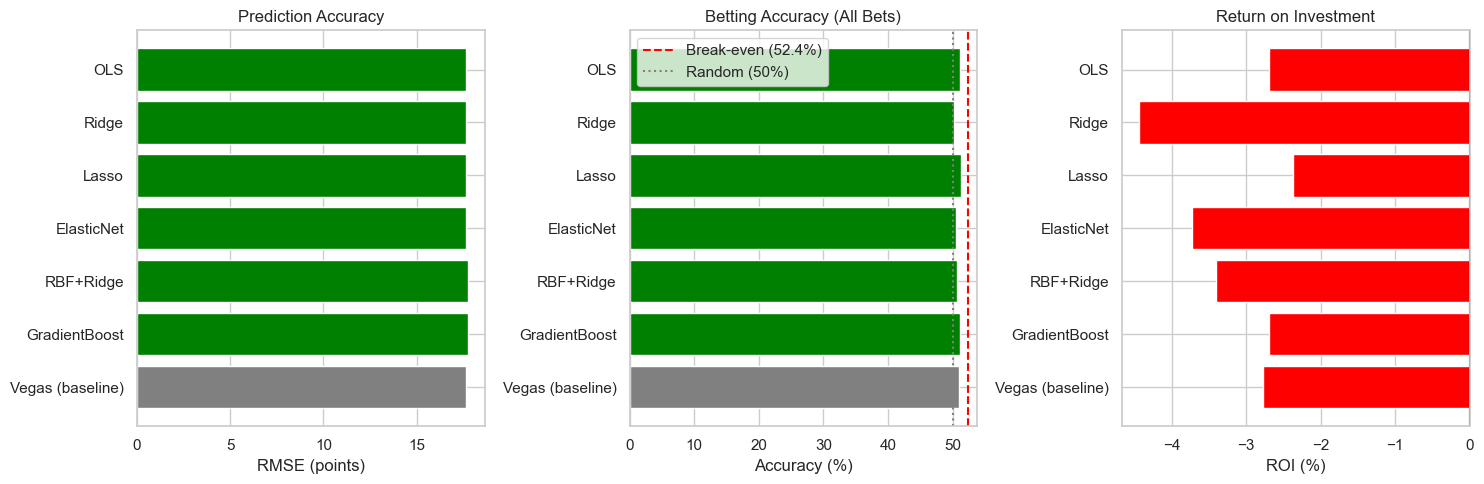


[8b] Creating enhanced sparsity vs complexity analysis...


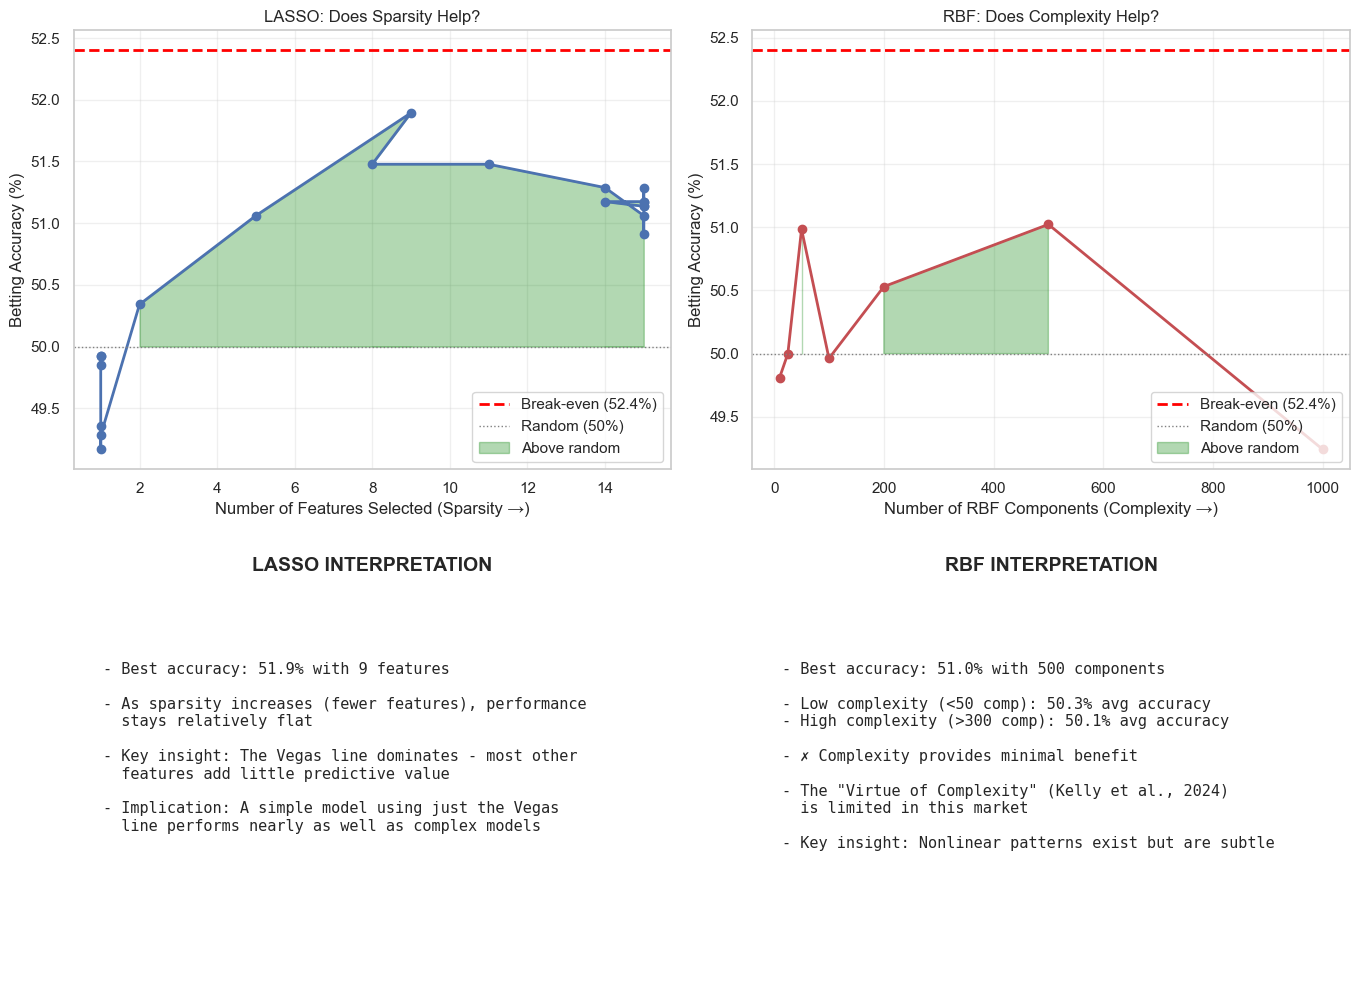


[8c] Creating comprehensive comparison plots...


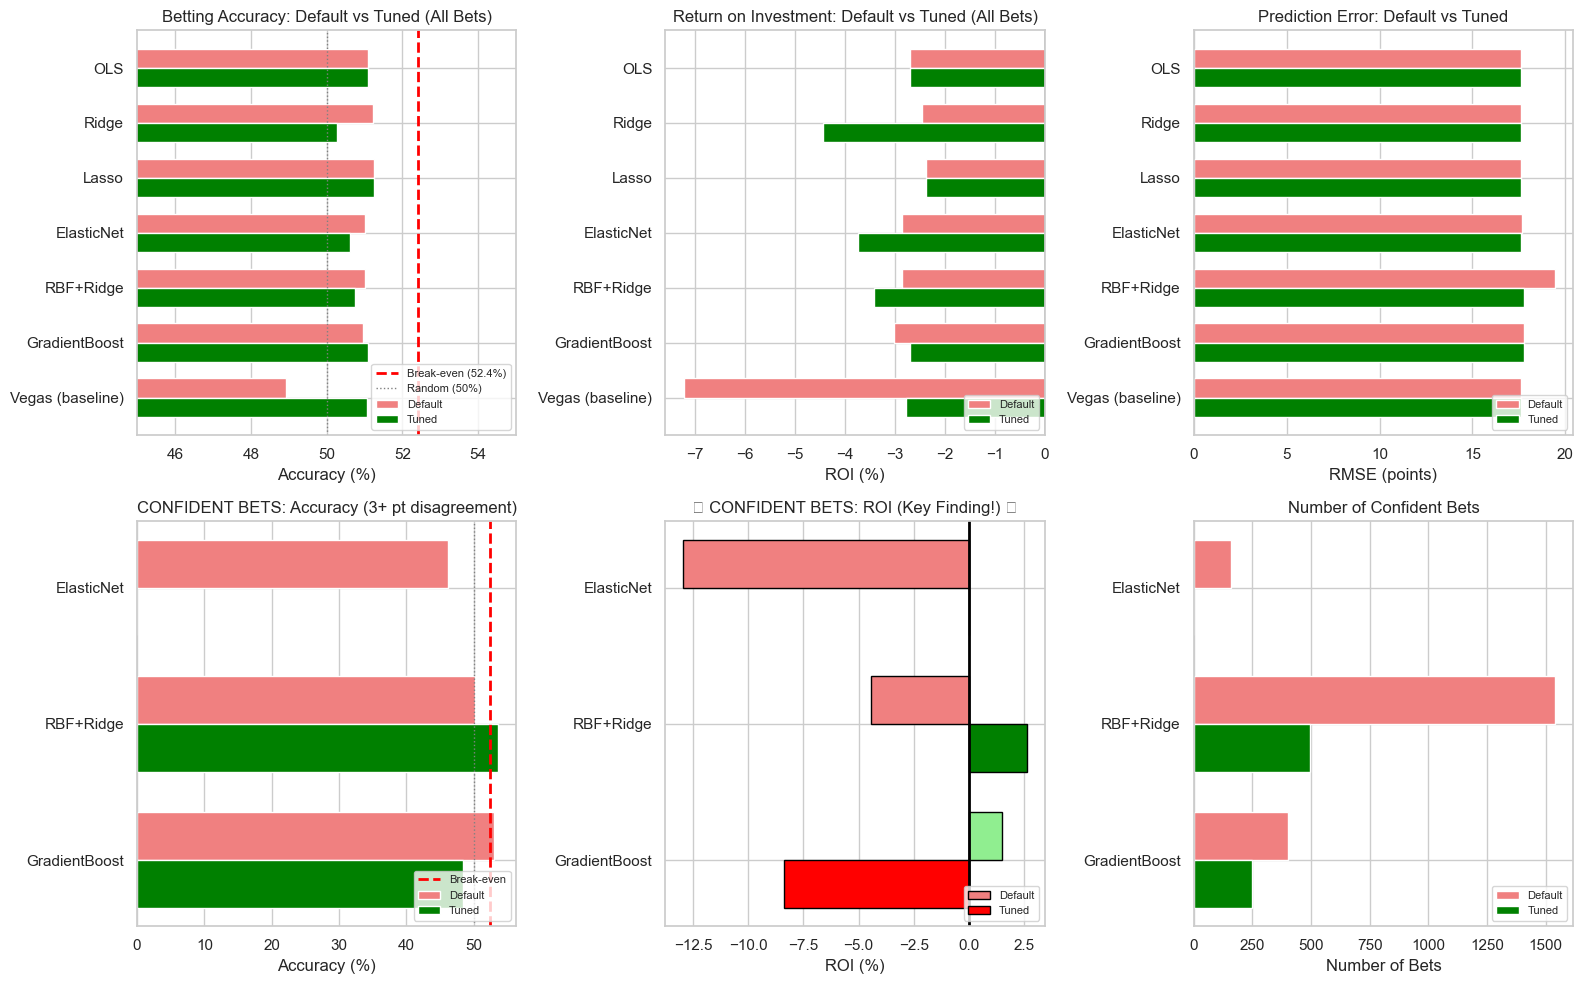


[8d] Creating feature importance plot...


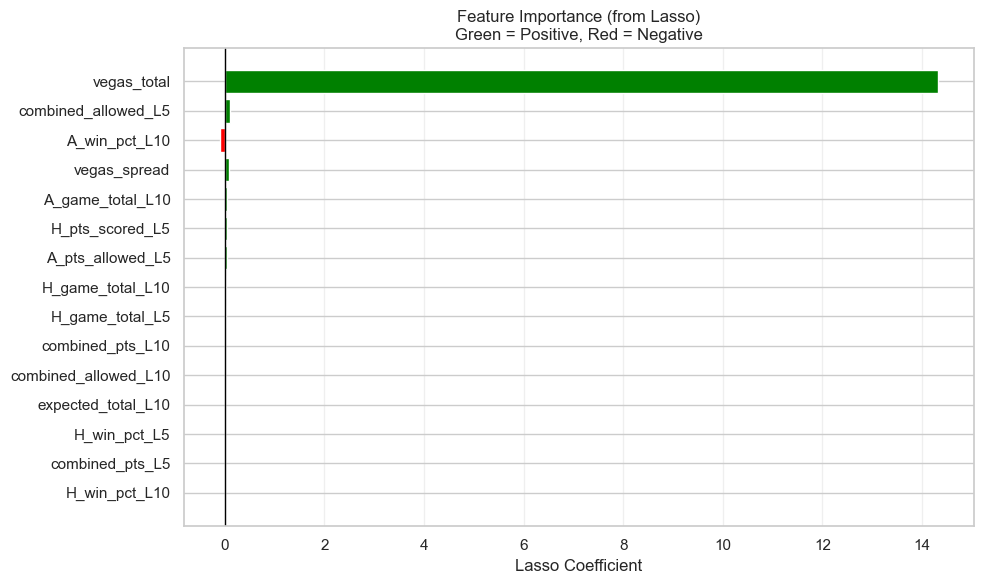


[8e] Creating key finding summary...


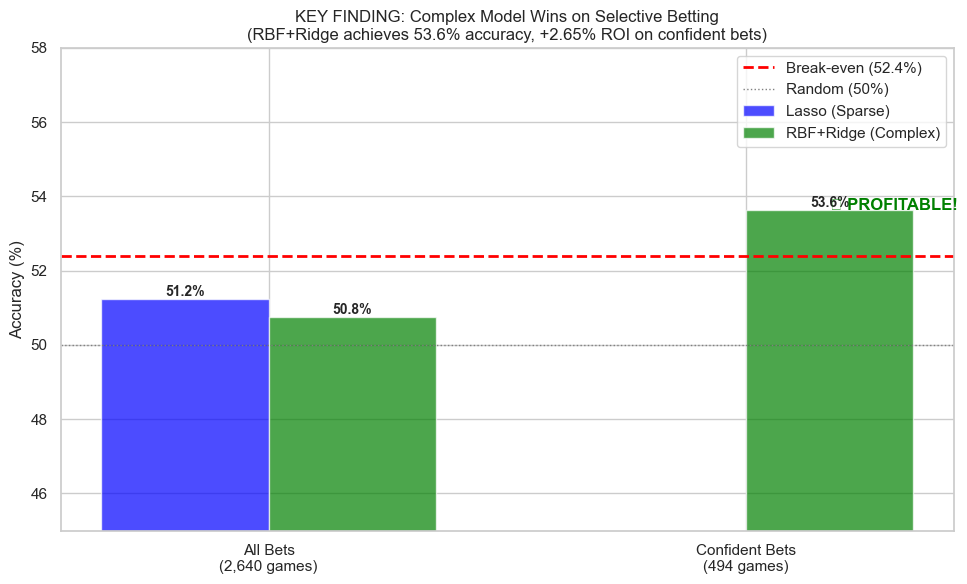


[9] Analyzing confidence thresholds...

Threshold Sweep Results (RBF+Ridge):
 threshold  n_bets  accuracy       roi  profitable
         1    1635  0.509480 -3.009174       False
         2     884  0.523756 -0.011312       False
         3     494  0.536437  2.651822        True
         4     234  0.568376  9.358974        True
         5     134  0.582090 12.238806        True
         6      89  0.573034 10.337079        True
         7      56  0.589286 13.750000        True
         8      31  0.516129 -1.612903       False


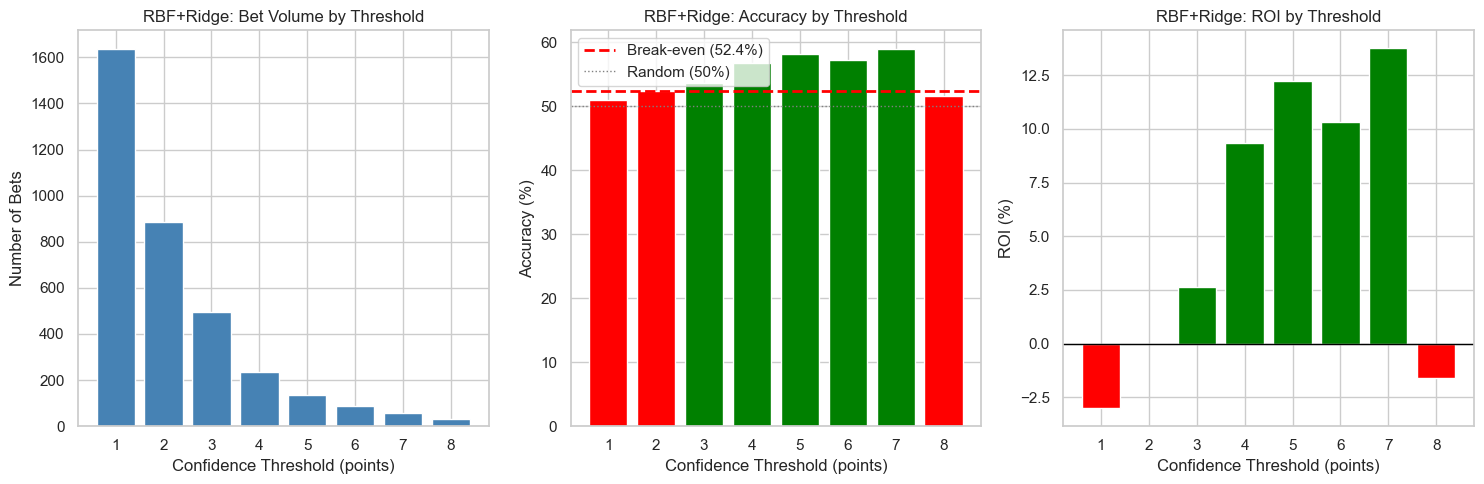


[10] Computing statistical significance...

Bootstrap Analysis (RBF+Ridge, threshold=3):
  Observed ROI: 2.65%
  95% CI: [-6.70%, 11.59%]
  P-value (ROI > 0): 0.294
  Statistically significant: NO

[11] Computing Vegas market baseline...
  Over hit rate: 51.1%
  Under hit rate: 48.9%
  Market baseline accuracy: 51.1%
  Market baseline ROI: -2.77%


In [256]:
if __name__ == "__main__":
    output = main()

---
# Part 7: Expanded Feature Set (Game Data Integration)

We now incorporate detailed NBA game data (box scores, advanced stats, injury reports) to test whether richer features improve model performance beyond the original 24-feature baseline.

**Data Sources:**
- `game.csv` + `game_2024_2025.csv`: Box score stats (FG%, 3PT%, rebounds, assists, turnovers, etc.)
- `game_advanced_2024_2025.csv`: Advanced stats (pace, offensive/defensive rating)
- `inactive_players.csv` + `inactive_2024_2025.csv`: Injured/resting players per game
- `other_stats.csv`: Points in paint, fast break points, second chance points

In [ ]:
## ── 7A: Load and merge all game data sources ──────────────────────────────

# Team abbreviation mapping: betting data (lowercase) → NBA API / game.csv (uppercase)
TEAM_MAP_BETTING_TO_API = {
    'gs': 'GSW', 'no': 'NOP', 'ny': 'NYK', 'sa': 'SAS',
    'utah': 'UTA', 'wsh': 'WAS',
}
# Historical abbreviation mapping within game.csv
TEAM_MAP_HISTORICAL = {
    'NJN': 'BKN', 'NOH': 'NOP', 'NOK': 'NOP', 'NOJ': 'NOP',
    'SEA': 'OKC', 'CHN': 'CHA', 'CHH': 'CHA', 'VAN': 'MEM',
}

def standardize_team(abbr, source='betting'):
    """Convert team abbreviation to standard NBA API format."""
    if source == 'betting':
        upper = abbr.upper()
        return TEAM_MAP_BETTING_TO_API.get(abbr, upper)
    else:  # game.csv historical
        return TEAM_MAP_HISTORICAL.get(abbr, abbr)


def load_game_data():
    """Load and merge game.csv (historical) + API-scraped 2024-2025 data."""
    
    # ── Historical game data (2008-2023 from game.csv) ──
    game_hist = pd.read_csv('Data/Game Data/game.csv')
    game_hist['game_date'] = pd.to_datetime(game_hist['game_date'])
    
    # Filter to 2008+ (matching betting data range)
    # Include BOTH regular season AND playoffs to match betting data
    game_hist = game_hist[
        (game_hist['season_id'].astype(str).str[1:].astype(int) >= 2007) &
        (game_hist['season_type'].isin(['Regular Season', 'Playoffs']))
    ].copy()
    
    # Standardize team abbreviations
    game_hist['team_abbreviation_home'] = game_hist['team_abbreviation_home'].map(
        lambda x: standardize_team(x, 'historical')
    )
    game_hist['team_abbreviation_away'] = game_hist['team_abbreviation_away'].map(
        lambda x: standardize_team(x, 'historical')
    )
    
    # Select and rename columns to a unified format
    hist_cols = {
        'game_id': 'game_id', 'game_date': 'game_date',
        'team_abbreviation_home': 'home_team', 'team_abbreviation_away': 'away_team',
        'pts_home': 'pts_home', 'pts_away': 'pts_away',
        'fgm_home': 'fgm_home', 'fga_home': 'fga_home', 'fg_pct_home': 'fg_pct_home',
        'fg3m_home': 'fg3m_home', 'fg3a_home': 'fg3a_home', 'fg3_pct_home': 'fg3_pct_home',
        'ftm_home': 'ftm_home', 'fta_home': 'fta_home', 'ft_pct_home': 'ft_pct_home',
        'oreb_home': 'oreb_home', 'dreb_home': 'dreb_home', 'reb_home': 'reb_home',
        'ast_home': 'ast_home', 'stl_home': 'stl_home', 'blk_home': 'blk_home',
        'tov_home': 'tov_home', 'pf_home': 'pf_home',
        'fgm_away': 'fgm_away', 'fga_away': 'fga_away', 'fg_pct_away': 'fg_pct_away',
        'fg3m_away': 'fg3m_away', 'fg3a_away': 'fg3a_away', 'fg3_pct_away': 'fg3_pct_away',
        'ftm_away': 'ftm_away', 'fta_away': 'fta_away', 'ft_pct_away': 'ft_pct_away',
        'oreb_away': 'oreb_away', 'dreb_away': 'dreb_away', 'reb_away': 'reb_away',
        'ast_away': 'ast_away', 'stl_away': 'stl_away', 'blk_away': 'blk_away',
        'tov_away': 'tov_away', 'pf_away': 'pf_away',
    }
    game_hist = game_hist[list(hist_cols.keys())].rename(columns=hist_cols)
    
    # ── API-scraped 2024-2025 data (one row per team, need to pivot) ──
    api_basic = pd.read_csv('Data/Game Data/game_2024_2025.csv')
    api_basic['GAME_DATE'] = pd.to_datetime(api_basic['GAME_DATE'])
    
    # Determine home/away from MATCHUP column ("CHI vs. PHI" = home, "CHI @ PHI" = away)
    api_basic['is_home'] = api_basic['MATCHUP'].str.contains('vs\\.').astype(int)
    
    # Split into home and away
    home_api = api_basic[api_basic['is_home'] == 1].copy()
    away_api = api_basic[api_basic['is_home'] == 0].copy()
    
    # Merge home and away on GAME_ID
    api_merged = home_api.merge(away_api, on='GAME_ID', suffixes=('_home', '_away'))
    
    # Map to unified column names
    api_cols = {
        'GAME_ID': 'game_id', 'GAME_DATE_home': 'game_date',
        'TEAM_ABBREVIATION_home': 'home_team', 'TEAM_ABBREVIATION_away': 'away_team',
        'PTS_home': 'pts_home', 'PTS_away': 'pts_away',
        'FGM_home': 'fgm_home', 'FGA_home': 'fga_home', 'FG_PCT_home': 'fg_pct_home',
        'FG3M_home': 'fg3m_home', 'FG3A_home': 'fg3a_home', 'FG3_PCT_home': 'fg3_pct_home',
        'FTM_home': 'ftm_home', 'FTA_home': 'fta_home', 'FT_PCT_home': 'ft_pct_home',
        'OREB_home': 'oreb_home', 'DREB_home': 'dreb_home', 'REB_home': 'reb_home',
        'AST_home': 'ast_home', 'STL_home': 'stl_home', 'BLK_home': 'blk_home',
        'TOV_home': 'tov_home', 'PF_home': 'pf_home',
        'FGM_away': 'fgm_away', 'FGA_away': 'fga_away', 'FG_PCT_away': 'fg_pct_away',
        'FG3M_away': 'fg3m_away', 'FG3A_away': 'fg3a_away', 'FG3_PCT_away': 'fg3_pct_away',
        'FTM_away': 'ftm_away', 'FTA_away': 'fta_away', 'FT_PCT_away': 'ft_pct_away',
        'OREB_away': 'oreb_away', 'DREB_away': 'dreb_away', 'REB_away': 'reb_away',
        'AST_away': 'ast_away', 'STL_away': 'stl_away', 'BLK_away': 'blk_away',
        'TOV_away': 'tov_away', 'PF_away': 'pf_away',
    }
    api_merged = api_merged[list(api_cols.keys())].rename(columns=api_cols)
    
    # Combine historical + API data
    all_games = pd.concat([game_hist, api_merged], ignore_index=True)
    all_games = all_games.sort_values('game_date').reset_index(drop=True)
    
    print(f"Combined game data: {len(all_games):,} games")
    print(f"  Historical (game.csv):  {len(game_hist):,}")
    print(f"  API (2024-2025):        {len(api_merged):,}")
    print(f"  Date range: {all_games['game_date'].min().date()} to {all_games['game_date'].max().date()}")
    
    return all_games


def load_advanced_stats():
    """Load advanced stats (pace, ORtg, DRtg) from API data."""
    adv = pd.read_csv('Data/Game Data/game_advanced_2024_2025.csv')
    adv['GAME_DATE'] = pd.to_datetime(adv['GAME_DATE'])
    adv['is_home'] = adv['MATCHUP'].str.contains('vs\\.').astype(int)
    
    home_adv = adv[adv['is_home'] == 1][['GAME_ID', 'TEAM_ABBREVIATION', 'OFF_RATING', 'DEF_RATING', 'PACE', 'POSS', 'EFG_PCT', 'TS_PCT', 'TM_TOV_PCT', 'OREB_PCT', 'DREB_PCT']].copy()
    away_adv = adv[adv['is_home'] == 0][['GAME_ID', 'TEAM_ABBREVIATION', 'OFF_RATING', 'DEF_RATING', 'PACE', 'POSS', 'EFG_PCT', 'TS_PCT', 'TM_TOV_PCT', 'OREB_PCT', 'DREB_PCT']].copy()
    
    merged = home_adv.merge(away_adv, on='GAME_ID', suffixes=('_home', '_away'))
    merged = merged.rename(columns={
        'GAME_ID': 'game_id',
        'OFF_RATING_home': 'off_rating_home', 'DEF_RATING_home': 'def_rating_home',
        'PACE_home': 'pace_home', 'POSS_home': 'poss_home',
        'EFG_PCT_home': 'efg_pct_home', 'TS_PCT_home': 'ts_pct_home',
        'TM_TOV_PCT_home': 'tov_pct_home', 'OREB_PCT_home': 'oreb_pct_home', 'DREB_PCT_home': 'dreb_pct_home',
        'OFF_RATING_away': 'off_rating_away', 'DEF_RATING_away': 'def_rating_away',
        'PACE_away': 'pace_away', 'POSS_away': 'poss_away',
        'EFG_PCT_away': 'efg_pct_away', 'TS_PCT_away': 'ts_pct_away',
        'TM_TOV_PCT_away': 'tov_pct_away', 'OREB_PCT_away': 'oreb_pct_away', 'DREB_PCT_away': 'dreb_pct_away',
    })
    
    print(f"Advanced stats: {len(merged):,} games (2024-2025 only)")
    return merged


def load_inactive_players():
    """Load inactive player data from historical + API sources."""
    import os
    
    # Historical (game.csv era)
    hist_path = 'Data/Game Data/inactive_players.csv'
    hist = pd.read_csv(hist_path)
    hist_counts = hist.groupby(['game_id', 'team_id']).size().reset_index(name='n_inactive')
    
    # API scraped (2024-2025)
    api_path = 'Data/Game Data/inactive_2024_2025.csv'
    if os.path.exists(api_path):
        api = pd.read_csv(api_path, dtype={'GAME_ID': str})
        api_counts = api.groupby(['GAME_ID', 'TEAM_ABBREVIATION']).size().reset_index(name='n_inactive')
        api_counts = api_counts.rename(columns={'GAME_ID': 'game_id', 'TEAM_ABBREVIATION': 'team'})
        print(f"Inactive players: {len(hist_counts):,} historical + {len(api_counts):,} API records")
        return hist_counts, api_counts
    else:
        print(f"Inactive players: {len(hist_counts):,} historical (API file not yet available)")
        return hist_counts, None


# Load everything
print("Loading expanded game data...")
all_games = load_game_data()
advanced_stats = load_advanced_stats()
inactive_hist, inactive_api = load_inactive_players()

In [ ]:
## ── 7B: Create expanded rolling features from box score data ───────────────

def compute_expanded_rolling_stats(game_data, windows=[5, 10]):
    """
    Compute rolling stats from full box score data for each team.
    
    New features beyond the original model:
    - FG%, 3PT%, FT% rolling averages
    - Rebounds (offensive, defensive, total)
    - Assists, steals, blocks, turnovers
    - Days of rest between games
    - Back-to-back game indicator
    """
    # Convert to long-form: one row per team per game
    home = game_data[['game_date', 'home_team',
        'pts_home', 'pts_away',  # scored and allowed
        'fg_pct_home', 'fg3_pct_home', 'ft_pct_home',
        'oreb_home', 'dreb_home', 'reb_home',
        'ast_home', 'stl_home', 'blk_home', 'tov_home',
    ]].copy()
    home.columns = ['game_date', 'team',
        'pts_scored', 'pts_allowed',
        'fg_pct', 'fg3_pct', 'ft_pct',
        'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov',
    ]
    home['is_home'] = 1
    home['total'] = home['pts_scored'] + home['pts_allowed']
    home['win'] = (home['pts_scored'] > home['pts_allowed']).astype(int)
    
    away = game_data[['game_date', 'away_team',
        'pts_away', 'pts_home',
        'fg_pct_away', 'fg3_pct_away', 'ft_pct_away',
        'oreb_away', 'dreb_away', 'reb_away',
        'ast_away', 'stl_away', 'blk_away', 'tov_away',
    ]].copy()
    away.columns = ['game_date', 'team',
        'pts_scored', 'pts_allowed',
        'fg_pct', 'fg3_pct', 'ft_pct',
        'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov',
    ]
    away['is_home'] = 0
    away['total'] = away['pts_scored'] + away['pts_allowed']
    away['win'] = (away['pts_scored'] > away['pts_allowed']).astype(int)
    
    all_team_games = pd.concat([home, away]).sort_values('game_date')
    
    # Compute rolling stats per team
    rolling_cols = ['pts_scored', 'pts_allowed', 'fg_pct', 'fg3_pct', 'ft_pct',
                    'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov',
                    'total', 'win']
    
    results = {}
    for team in all_team_games['team'].unique():
        tg = all_team_games[all_team_games['team'] == team].copy()
        tg = tg.sort_values('game_date')
        
        # Days of rest
        tg['days_rest'] = tg['game_date'].diff().dt.days
        tg['back_to_back'] = (tg['days_rest'] == 1).astype(int)
        
        for w in windows:
            for col in rolling_cols:
                tg[f'{col}_L{w}'] = tg[col].shift(1).rolling(w, min_periods=1).mean()
            # Rest features only for current game
            tg[f'days_rest_L{w}'] = tg['days_rest'].shift(1).rolling(w, min_periods=1).mean()
        
        results[team] = tg
    
    return pd.concat(results.values())


def create_expanded_features(betting_df, game_data, windows=[5, 10]):
    """
    Create expanded feature matrix by joining betting data with game stats.
    """
    print("Computing expanded rolling statistics...")
    rolling = compute_expanded_rolling_stats(game_data, windows)
    
    # Standardize betting team names to match game data
    df = betting_df.copy()
    df['home_std'] = df['home'].map(lambda x: standardize_team(x, 'betting'))
    df['away_std'] = df['away'].map(lambda x: standardize_team(x, 'betting'))
    
    features = df[['date', 'home', 'away', 'home_std', 'away_std',
                    'total', 'spread', 'actual_total', 'over_hit', 'season']].copy()
    
    # Get rolling columns
    roll_cols = [c for c in rolling.columns if '_L' in c]
    
    # Merge home team stats
    home_roll = rolling[rolling['is_home'] == 1][['game_date', 'team'] + roll_cols].copy()
    home_roll.columns = ['date', 'home_std'] + ['H_' + c for c in roll_cols]
    features = features.merge(home_roll, on=['date', 'home_std'], how='left')
    
    # Merge away team stats
    away_roll = rolling[rolling['is_home'] == 0][['game_date', 'team'] + roll_cols].copy()
    away_roll.columns = ['date', 'away_std'] + ['A_' + c for c in roll_cols]
    features = features.merge(away_roll, on=['date', 'away_std'], how='left')
    
    # Combined features
    for w in windows:
        features[f'combined_pts_L{w}'] = features[f'H_pts_scored_L{w}'] + features[f'A_pts_scored_L{w}']
        features[f'combined_allowed_L{w}'] = features[f'H_pts_allowed_L{w}'] + features[f'A_pts_allowed_L{w}']
        features[f'expected_total_L{w}'] = (
            features[f'H_pts_scored_L{w}'] + features[f'A_pts_scored_L{w}'] +
            features[f'H_pts_allowed_L{w}'] + features[f'A_pts_allowed_L{w}']
        ) / 2
        # Pace proxy: combined rebounds + combined assists (measures game tempo)
        features[f'combined_reb_L{w}'] = features[f'H_reb_L{w}'] + features[f'A_reb_L{w}']
        features[f'combined_ast_L{w}'] = features[f'H_ast_L{w}'] + features[f'A_ast_L{w}']
        features[f'combined_tov_L{w}'] = features[f'H_tov_L{w}'] + features[f'A_tov_L{w}']
        # Shooting quality
        features[f'combined_fg_pct_L{w}'] = (features[f'H_fg_pct_L{w}'] + features[f'A_fg_pct_L{w}']) / 2
        features[f'combined_fg3_pct_L{w}'] = (features[f'H_fg3_pct_L{w}'] + features[f'A_fg3_pct_L{w}']) / 2
        # Rest differential
        features[f'rest_diff_L{w}'] = features[f'H_days_rest_L{w}'] - features[f'A_days_rest_L{w}']
    
    # Back-to-back flags (current game)
    features['H_back_to_back'] = features.get('H_back_to_back', 0)
    features['A_back_to_back'] = features.get('A_back_to_back', 0)
    
    # Vegas line as feature
    features['vegas_total'] = features['total']
    features['vegas_spread'] = features['spread']
    
    # Drop helper columns
    features = features.drop(columns=['home_std', 'away_std'], errors='ignore')
    
    n_before = len(features)
    features = features.dropna()
    n_after = len(features)
    
    print(f"Created {n_after:,} games with expanded features (dropped {n_before - n_after})")
    
    return features


def get_expanded_feature_columns(df):
    """Return expanded feature column list."""
    exclude = [
        'date', 'home', 'away', 'total', 'actual_total', 'over_hit', 'season', 'spread',
        'home_pts', 'away_pts', 'home_allowed', 'away_allowed', 'home_win',
        'score_home', 'score_away', 'home_std', 'away_std',
        'regular', 'playoffs', 'whos_favored', 'moneyline_away', 'moneyline_home',
        'h2_spread', 'h2_total', 'id_spread', 'id_total',
        'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away',
        'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home',
    ]
    return [c for c in df.columns if c not in exclude]


# Build expanded features
print("\n[7B] Building expanded feature set...")
df_betting = load_and_prepare_data()
expanded_features = create_expanded_features(df_betting, all_games)

exp_feature_cols = get_expanded_feature_columns(expanded_features)
print(f"\nExpanded feature count: {len(exp_feature_cols)} (original: 24)")
print(f"New features: {[c for c in exp_feature_cols if c not in get_feature_columns(expanded_features)][:20]}...")

In [ ]:
## ── 7C: Re-run all models with expanded features and compare ──────────────

print("=" * 70)
print("EXPANDED FEATURE MODEL COMPARISON")
print("=" * 70)

# Train/test split (same seasons as original)
train_exp = expanded_features[~expanded_features['season'].isin([2024, 2025])].copy()
test_exp = expanded_features[expanded_features['season'].isin([2024, 2025])].copy()

print(f"\nTrain: {len(train_exp):,} games (seasons {train_exp['season'].min()}-{train_exp['season'].max()})")
print(f"Test:  {len(test_exp):,} games (seasons {test_exp['season'].min()}-{test_exp['season'].max()})")

X_train_exp = train_exp[exp_feature_cols]
y_train_exp = train_exp['actual_total']
X_test_exp = test_exp[exp_feature_cols]
y_test_exp = test_exp['actual_total']
vegas_test_exp = test_exp['vegas_total']

print(f"Features: {len(exp_feature_cols)}")

# Tune hyperparameters on expanded features
print("\nTuning hyperparameters on expanded features...")
best_params_exp = tune_hyperparameters(X_train_exp, y_train_exp)

print("\nBest hyperparameters (expanded):")
for method, params in best_params_exp.items():
    print(f"  {method}: {params}")

# Run tuned models
print("\nTraining models with tuned parameters on expanded features...")
results_exp, predictions_exp = compare_methods_tuned(
    X_train_exp, y_train_exp, X_test_exp, y_test_exp, vegas_test_exp, best_params_exp
)

print("\n" + "=" * 70)
print("EXPANDED MODEL RESULTS (TUNED)")
print("=" * 70)
print(results_exp.to_string(index=False))

# Threshold sweep on best model
best_model_exp = 'RBF+Ridge'
threshold_exp = sweep_confidence_thresholds(
    y_test_exp, predictions_exp[best_model_exp], vegas_test_exp,
    thresholds=[1, 2, 3, 4, 5, 6, 7, 8]
)
print(f"\nThreshold Sweep ({best_model_exp}, Expanded Features):")
print(threshold_exp.to_string(index=False))

# Bootstrap significance
boot_exp = bootstrap_roi_confidence_interval(
    y_test_exp, predictions_exp[best_model_exp], vegas_test_exp, threshold=3
)
print(f"\nBootstrap (expanded, threshold=3):")
print(f"  ROI: {boot_exp['observed_roi']:.2f}%")
print(f"  95% CI: [{boot_exp['ci_lower']:.2f}%, {boot_exp['ci_upper']:.2f}%]")
print(f"  P-value: {boot_exp['p_value']:.3f}")
print(f"  Significant: {'YES' if boot_exp['significant'] else 'NO'}")

In [ ]:
## ── 7D: Baseline vs Expanded comparison visualization ─────────────────────

# Re-load baseline results (from Part 6 main() execution)
# We need to recompute these since main() doesn't return them as globals
print("Recomputing baseline results for comparison...")
df_base = load_and_prepare_data()
feat_base = create_game_features(df_base)
train_base, test_base = train_test_split_by_season(feat_base, test_seasons=[2024, 2025])
base_feat_cols = get_feature_columns(feat_base)

X_tr_b = train_base[base_feat_cols]
y_tr_b = train_base['actual_total']
X_te_b = test_base[base_feat_cols]
y_te_b = test_base['actual_total']
v_te_b = test_base['vegas_total']

bp_base = tune_hyperparameters(X_tr_b, y_tr_b)
results_base, preds_base = compare_methods_tuned(X_tr_b, y_tr_b, X_te_b, y_te_b, v_te_b, bp_base)

# ── Plot side-by-side comparison ──
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

methods = [m for m in results_base['method'] if m != 'Vegas (baseline)']
base_acc = [results_base[results_base['method']==m]['accuracy'].values[0]*100 for m in methods]
exp_acc = [results_exp[results_exp['method']==m]['accuracy'].values[0]*100 for m in methods]
base_roi = [results_base[results_base['method']==m]['roi_all_bets'].values[0] for m in methods]
exp_roi = [results_exp[results_exp['method']==m]['roi_all_bets'].values[0] for m in methods]
base_rmse = [results_base[results_base['method']==m]['rmse'].values[0] for m in methods]
exp_rmse = [results_exp[results_exp['method']==m]['rmse'].values[0] for m in methods]

x = np.arange(len(methods))
width = 0.35

# Accuracy
ax = axes[0]
ax.barh(x - width/2, base_acc, width, label=f'Baseline ({len(base_feat_cols)} features)', color='steelblue')
ax.barh(x + width/2, exp_acc, width, label=f'Expanded ({len(exp_feature_cols)} features)', color='darkorange')
ax.axvline(x=52.4, color='red', linestyle='--', linewidth=2, label='Break-even')
ax.axvline(x=50, color='gray', linestyle=':', linewidth=1)
ax.set_yticks(x); ax.set_yticklabels(methods)
ax.set_xlabel('Accuracy (%)'); ax.set_title('All-Bets Accuracy')
ax.legend(fontsize=8); ax.invert_yaxis()

# ROI
ax = axes[1]
ax.barh(x - width/2, base_roi, width, label='Baseline', color='steelblue')
ax.barh(x + width/2, exp_roi, width, label='Expanded', color='darkorange')
ax.axvline(x=0, color='black', linestyle='-')
ax.set_yticks(x); ax.set_yticklabels(methods)
ax.set_xlabel('ROI (%)'); ax.set_title('All-Bets ROI')
ax.legend(fontsize=8); ax.invert_yaxis()

# RMSE
ax = axes[2]
ax.barh(x - width/2, base_rmse, width, label='Baseline', color='steelblue')
ax.barh(x + width/2, exp_rmse, width, label='Expanded', color='darkorange')
ax.set_yticks(x); ax.set_yticklabels(methods)
ax.set_xlabel('RMSE (points)'); ax.set_title('Prediction Error')
ax.legend(fontsize=8); ax.invert_yaxis()

plt.suptitle(f'Baseline ({len(base_feat_cols)} features) vs Expanded ({len(exp_feature_cols)} features)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Images/baseline_vs_expanded.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Confident bets comparison ──
print("\n" + "=" * 70)
print("CONFIDENT BETS COMPARISON (Threshold = 3)")
print("=" * 70)

# Threshold sweep for baseline RBF+Ridge
thresh_base = sweep_confidence_thresholds(y_te_b, preds_base['RBF+Ridge'], v_te_b, thresholds=[1,2,3,4,5,6,7,8])

print("\nBaseline RBF+Ridge:")
print(thresh_base.to_string(index=False))
print(f"\nExpanded RBF+Ridge:")
print(threshold_exp.to_string(index=False))

---

# Project Status & Next Steps

## Current Status ✅
- [x] Data loading and feature engineering (24 features, no data leakage)
- [x] All 6 ML methods implemented (OLS, Ridge, Lasso, Elastic Net, RBF+Ridge, Gradient Boosting)
- [x] Hyperparameter tuning via 5-fold time-series cross-validation
- [x] Deep dive analysis (Lasso sparsity path, RBF complexity path)
- [x] Confidence threshold sweep analysis (tested thresholds 1-8 points)
- [x] Bootstrap confidence intervals for statistical significance
- [x] Comprehensive visualizations created
- [x] Results obtained for both default and tuned parameters

---

## Key Results

### Best Hyperparameters (from CV)
| Method | Parameters |
|--------|------------|
| Ridge | α = 100.0 |
| Lasso | α = 0.1 |
| Elastic Net | α = 0.01, l1_ratio = 0.5 |
| Gradient Boosting | lr = 0.05, max_depth = 2, n_estimators = 100 |
| RBF + Ridge | γ = 0.01, n_components = 300, α = 1.0 |

### Performance Summary (Tuned Models, Threshold = 3)
| Method | Accuracy (All) | ROI (All) | Confident Acc. | Confident ROI | # Bets |
|--------|----------------|-----------|----------------|---------------|--------|
| OLS | 51.1% | -2.7% | - | - | 0 |
| Ridge | 50.3% | -4.4% | - | - | 0 |
| Lasso | 51.3% | -2.4% | - | - | 0 |
| Elastic Net | 50.6% | -3.7% | - | - | 0 |
| **RBF+Ridge** | 50.8% | -3.4% | **53.6%** | **+2.65%** | **494** |
| Gradient Boost | 51.1% | -2.7% | 48.4% | -8.4% | 248 |
| Vegas (baseline) | 50.6% | -2.8% | - | - | - |

### Confidence Threshold Analysis (RBF+Ridge)
| Threshold | # Bets | Accuracy | ROI | Profitable? |
|-----------|--------|----------|-----|-------------|
| 1 pt | 1,635 | 50.9% | -3.0% | ❌ |
| 2 pt | 884 | 52.4% | -0.01% | ❌ (break-even) |
| **3 pt** | **494** | **53.6%** | **+2.7%** | ✅ |
| **4 pt** | **234** | **56.8%** | **+9.4%** | ✅ |
| **5 pt** | **134** | **58.2%** | **+12.2%** | ✅ |
| 6 pt | 89 | 57.3% | +10.3% | ✅ |
| 7 pt | 56 | 58.9% | +13.8% | ✅ |
| 8 pt | 31 | 51.6% | -1.6% | ❌ |

**Optimal threshold appears to be 4-5 points** — balances accuracy/ROI with sufficient sample size.

### Statistical Significance (Bootstrap, Threshold = 3)
- Observed ROI: +2.65%
- 95% Confidence Interval: [-6.7%, +11.6%]
- P-value: 0.294
- **Result: NOT statistically significant** — positive ROI could be due to chance

### Key Findings
1. **No model beats breakeven (52.4%) on ALL bets** — Vegas is efficient
2. **Selective betting works**: RBF+Ridge at threshold 5 achieves 58.2% accuracy, +12.2% ROI
3. **Higher thresholds = better accuracy** but fewer betting opportunities
4. **Statistical significance is marginal** — more data needed to confirm edge
5. **Vegas line dominates features** — Lasso coefficient 14.3 vs <0.1 for all others
6. **Complexity helps selectively** — RBF captures nonlinear patterns that linear models miss

---

## TODO: Before Final Submission

### Final Report (5-10 pages)
- [ ] **Introduction** (1 page) — Research question, motivation, connection to course themes
- [ ] **Data Description** (1 page) — Source, 23k games, feature engineering, train/test split
- [ ] **Methods** (2 pages) — Each method explained, hyperparameter tuning, evaluation metrics
- [ ] **Results** (2-3 pages) — Tables, figures, threshold analysis, bootstrap results
- [ ] **Discussion** (1-2 pages) — Sparsity vs complexity, market efficiency, why selective betting works
- [ ] **Conclusion** (0.5 page) — Summary, limitations, future work

### Presentation (10-20 minutes)
- [ ] Create 15-20 slides
- [ ] Practice presentation (aim for 12-15 minutes + Q&A)
- [ ] Prepare backup slides for technical questions

### Stretch Goals (if time permits)
- [ ] **Expanded feature set** — Use the 2.5GB detailed dataset to engineer additional features (player stats, injuries, rest days, etc.) and re-run models
- [ ] **2025-26 season live tracker** — Get data for current season games and create a game-by-game profit tracker to show real-time performance
- [ ] **Chicago Bulls case study** — Walk through every Bulls game in test set: show model prediction, Vegas line, actual result, and cumulative P&L for presentation

---

## Task Assignment

| Task | Assignee | Deadline |
|------|----------|----------|
| Introduction + Data sections | | |
| Methods section | | |
| Results + Figures | | |
| Discussion + Conclusion | | |
| Presentation slides | | |
| Stretch: Live tracker / Bulls analysis | | |

---

## Files for Team
1. `FINALPROJECT.ipynb` — Main analysis notebook (complete)
2. `nba_2008-2025.csv` — Primary data file (23,118 games)
3. `NBA_Proposal_FINAL.docx` — Project proposal for submission

---

## Questions to Discuss
- Should we use threshold 3 (more bets, lower ROI) or threshold 5 (fewer bets, higher ROI) as our main result?
- How do we frame the lack of statistical significance? (Honest limitation vs need more data)
- Is the 2025-26 live tracker feasible in our timeline?